In [1]:
# Imports

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load

df = pd.read_csv("data/weather.csv", parse_dates = ["time"])
df.head()

,time,temperature_2m,relative_humidity_2m,dew_point_2m,precipitation,rain,snowfall,weather_code,cloud_cover,pressure_msl,surface_pressure,wind_speed_10m,wind_direction_10m,shortwave_radiation,vapour_pressure_deficit,soil_temperature_0_to_7cm
0,2000-01-01 00:00:00,-4.5,75,-8.3,0.2,0.0,0.14,71,96,1004.9,880.6,1.8,323,0.0,0.11,-2.1
1,2000-01-01 01:00:00,-4.5,76,-8.1,0.1,0.0,0.07,71,94,1004.8,880.6,3.3,319,0.0,0.11,-2.1
2,2000-01-01 02:00:00,-4.6,77,-8.0,0.0,0.0,0.07,71,98,1004.4,880.2,4.3,318,0.0,0.10,-2.1
3,2000-01-01 03:00:00,-4.7,76,-8.3,0.0,0.0,0.07,71,93,1004.0,879.8,4.1,315,0.0,0.11,-2.2
4,2000-01-01 04:00:00,-6.9,75,-10.6,0.0,0.0,0.07,71,97,1004.7,879.4,3.8,311,0.0,0.09,-3.6


In [3]:
# Inspect
# UPDATED

# Structure
print(df["time"].min(), "to", df["time"].max(), "\n")
print("Shape:", df.shape, "\n")
print("Dtypes:")
print(df.dtypes, "\n")

# Missingness
print("Missing Values:", df.isna().any().any(), "\n")

# Duplicates
print("Duplicated Rows:", df.duplicated().any(), "\n")
print("Duplicated Times:", df["time"].duplicated().any(), "\n")

# Sanity
print("Monotonic:", df["time"].is_monotonic_increasing, "\n")
print("Unexpected Time Gaps:", df["time"].diff().dropna().ne(pd.Timedelta(hours=1)).any(), "\n")

2000-01-01 00:00:00 to 2026-08-31 23:00:00 

Shape: (233760, 16) 

Dtypes:
time                         datetime64[us]
temperature_2m                      float64
relative_humidity_2m                  int64
dew_point_2m                        float64
precipitation                       float64
rain                                float64
snowfall                            float64
weather_code                          int64
cloud_cover                           int64
pressure_msl                        float64
surface_pressure                    float64
wind_speed_10m                      float64
wind_direction_10m                    int64
shortwave_radiation                 float64
vapour_pressure_deficit             float64
soil_temperature_0_to_7cm           float64
dtype: object 

Missing Values: False 

Duplicated Rows: False 

Duplicated Times: False 

Monotonic: True 

Unexpected Time Gaps: False 



In [4]:
# Clean
# No clean required after inspection.

In [5]:
# Transform

df = df.loc[df["time"].dt.year.eq(2025), ["time", "temperature_2m"]]

daily_range_df = (
    df.assign(date = lambda x: x["time"].dt.normalize())
      .groupby(["date"], as_index = False)
      .agg(min_temp = ("temperature_2m", "min"),
           max_temp = ("temperature_2m", "max")
          )
)

output_df = (
    daily_range_df.assign(month = lambda x: x["date"].dt.month_name())
                  .groupby(["month"], sort=False, as_index = False)
                  .agg(min_temp = ("min_temp", "mean"),
                       max_temp = ("max_temp", "mean")
                      )
                  .assign(temp_range = lambda x: x["max_temp"] - x["min_temp"])
)

output_df

,month,min_temp,max_temp,temp_range
0,January,-7.925806,0.248387,8.174194
1,February,-16.514286,-6.175000,10.339286
2,March,-3.964516,5.596774,9.561290
3,April,-0.806667,12.513333,13.320000
4,May,5.370968,19.803226,14.432258
5,June,8.533333,21.530000,12.996667
6,July,10.761290,21.496774,10.735484
7,August,10.516129,24.474194,13.958065
8,September,7.833333,23.650000,15.816667
9,October,0.770968,12.893548,12.122581


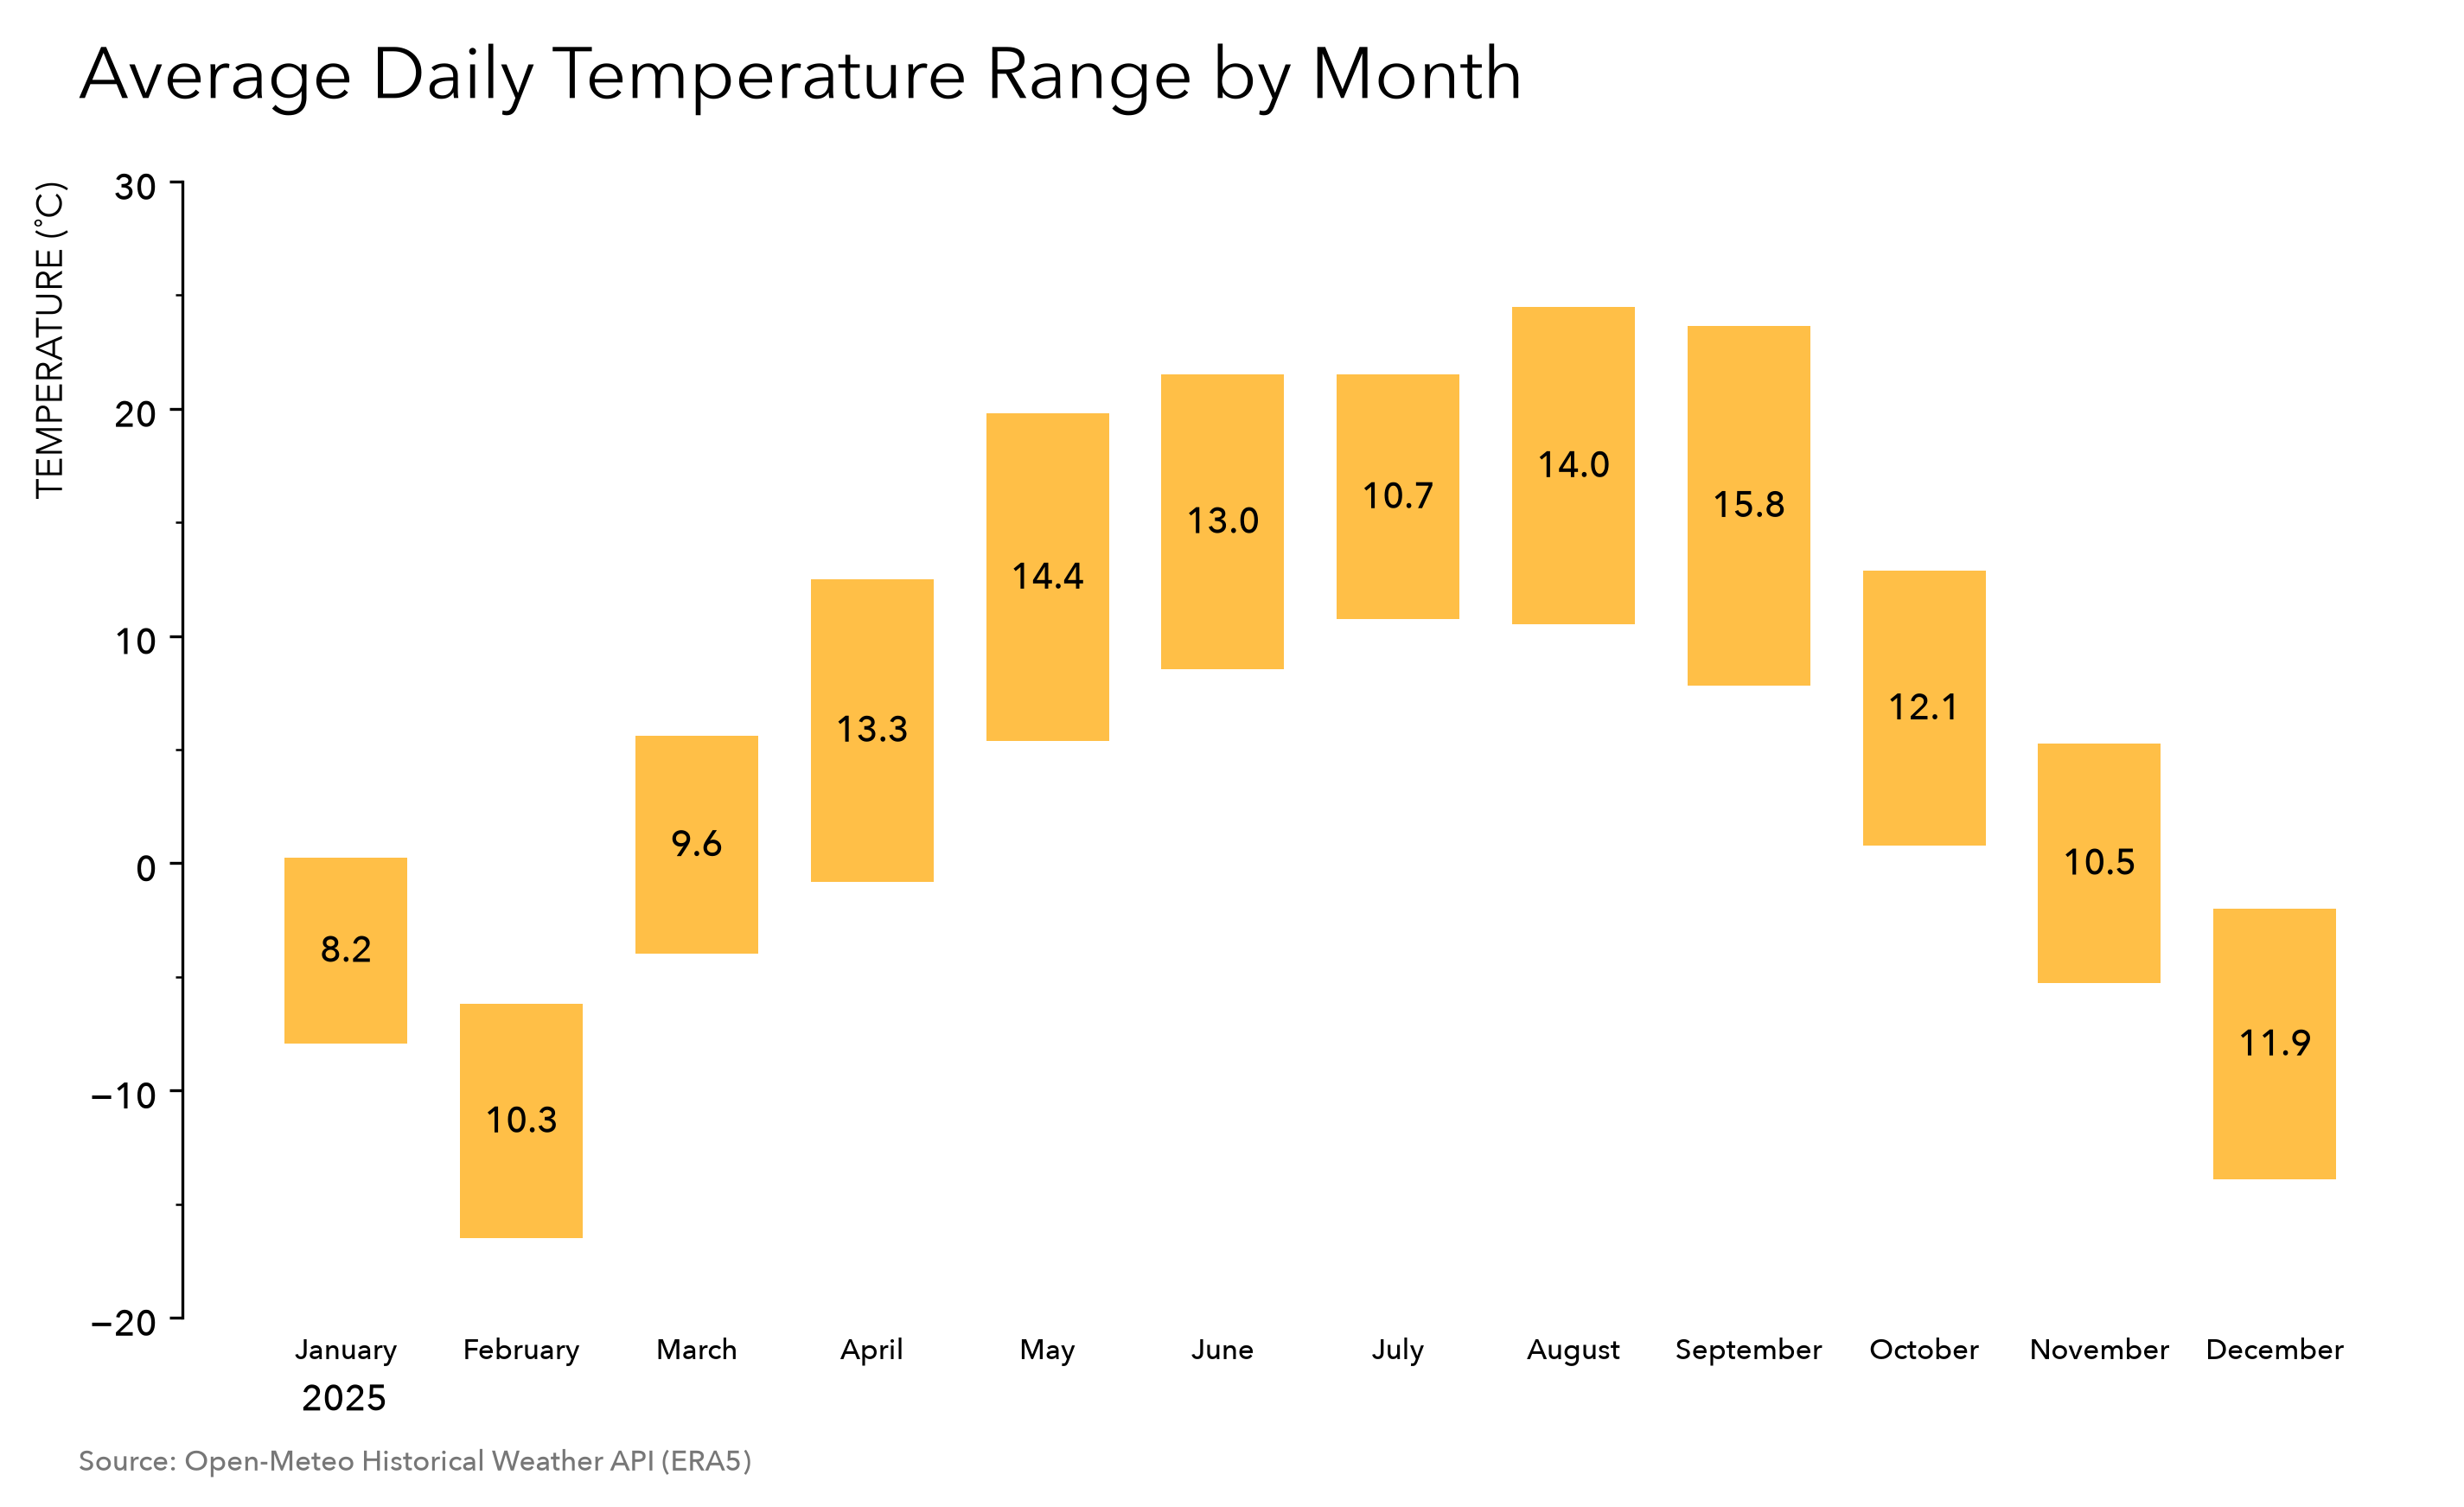

In [6]:
# Visualize

# Figure
plt.rcParams["font.family"] = "Avenir Next"
plt.rcParams["font.weight"] = 500

fig, ax = plt.subplots(figsize = (10, 6), dpi = 300)

fig.subplots_adjust(
    left = 0.1,
    right = 0.97,
    top = 0.86,
    bottom = 0.13
)

# Plot
range_bars = ax.bar(output_df["month"], output_df["temp_range"], bottom = output_df["min_temp"], width = 0.7, color = "#FFBF47")

# Emphasis

ax.bar_label(
    range_bars,
    labels=output_df["temp_range"].round(1),
    label_type="center"
)

# Scale & Axes

ax.set_ylim(-20, 30)

ax.set_ylabel("TEMPERATURE (˚C)", loc = "top", fontsize = 10)

ax.text(-0.01, -0.05, "2025", transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize = 10)

# Ticks
ax.set_yticks([-20, -10, 0, 10, 20, 30])
ax.set_yticks([-15, -5, 5, 10, 15, 25], minor=True)

ax.tick_params(
    axis = "y",
    labelsize = 10
)

ax.tick_params(
    axis = "x",
    length = 0,
    labelsize = 8
)

# Styling
for spine in ["top", "right", "bottom"]:
    ax.spines[spine].set_visible(False)

# Composition
fig.suptitle(
    "Average Daily Temperature Range by Month",
    x = 0.06,
    y = 0.96,
    ha = "left",
    fontsize = 20
)

fig.text(0.06, 0.025, "Source: Open-Meteo Historical Weather API (ERA5)", ha = "left", va = "bottom", fontsize = 8, color = "#777777")

# Output
fig.savefig("outputs/v3-avg_monthly-daily_temp_range-2025.svg", bbox_inches = "tight", pad_inches = 0.1)
plt.show()